# 11 · Powder X-ray Diffraction Workflows

**Where this sits in PyTex.** Notebook 04 gave $d$-spacings; Notebook 08 gave Bragg
geometry. Here we synthesise a full **powder X-ray diffraction** (XRD) pattern from a
`Phase` — peak positions, multiplicities, structure-factor-driven intensities, and
profile broadening — using PyTex's pinned fixture corpus so every number is reproducible.

## Learning goals

1. generate a powder pattern with `generate_xrd_pattern` and a chosen `RadiationSpec`;
2. verify peak positions against **Bragg's law** and the **FCC selection rules**;
3. read reflection **multiplicity** and **structure-factor** amplitudes;
4. plot the pattern, and see how changing the anode (Cu → Mo) shifts every peak.

## Theory

A powder is an ensemble of randomly oriented crystallites, so every plane family
$\{hkl\}$ that satisfies Bragg's law $\lambda = 2 d_{hkl}\sin\theta$ contributes a ring,
seen in a $\theta$–$2\theta$ scan as a peak at

$$
2\theta_{hkl} = 2\arcsin\!\left(\frac{\lambda}{2 d_{hkl}}\right).
$$

The peak *intensity* scales with the **structure factor**
$F_{hkl}=\sum_j f_j\,e^{2\pi i(hx_j+ky_j+lz_j)}$, the **multiplicity** of the family,
and geometric (Lorentz–polarization) factors. For FCC the structure factor vanishes
unless $h,k,l$ have the **same parity** (all even or all odd) — the systematic absences
that fingerprint the lattice type. (Cullity & Stock, *Elements of X-ray Diffraction*,
3rd ed., 2001; De Graef & McHenry 2012.)

> **Model caveat.** The default intensity model is a *kinematic proxy* using
> atomic-number scattering; it is meant for teaching peak positions, selection rules,
> and relative intensities — not for Rietveld-grade quantitative refinement.

In [1]:
from __future__ import annotations

import warnings

import numpy as np

warnings.filterwarnings("ignore", message="Issues encountered while parsing CIF")
warnings.filterwarnings("ignore", message="No _symmetry_equiv_pos_as_xyz")

from pytex import (
    FrameDomain,
    RadiationSpec,
    ReferenceFrame,
    generate_xrd_pattern,
    get_phase_fixture,
    plot_xrd_pattern,
)

np.set_printoptions(precision=4, suppress=True)

crystal = ReferenceFrame("crystal", FrameDomain.CRYSTAL, ("a", "b", "c"))
nickel = get_phase_fixture("ni_fcc").load_phase(crystal_frame=crystal)

## 1 · Generating a pattern

`generate_xrd_pattern` takes the phase, a radiation spec, and the scan window. We use
the Cu K$\alpha$ line ($\lambda = 1.5406$ Å). The returned `PowderPattern` carries both
the discrete reflection list and a continuous, profile-broadened intensity grid.

In [2]:
radiation = RadiationSpec.cu_ka()
pattern = generate_xrd_pattern(
    nickel, radiation=radiation,
    two_theta_range_deg=(20.0, 120.0), resolution_deg=0.02,
    max_index=6, broadening_fwhm_deg=0.16,
)
print(f"radiation      : {radiation.name}, lambda = {radiation.wavelength_angstrom:.4f} A")
print(f"reflections    : {len(pattern.reflections)} in 20-120 deg 2theta")
print(f"intensity grid : {pattern.intensity_grid.shape[0]} points")

radiation      : Cu Ka, lambda = 1.5406 A
reflections    : 5 in 20-120 deg 2theta
intensity grid : 5001 points


## 2 · Peak positions obey Bragg's law and FCC selection rules

Every reflection's $2\theta$ must equal the Bragg value computed from its $d$-spacing —
we assert this to machine precision. And *which* reflections appear is dictated by the
FCC rule: the list is exactly $111, 002, 022, 113, 222$, all of **unmixed parity**.
Mixed-parity planes like $(100)$ or $(110)$ are systematically absent.

In [3]:
lam = radiation.wavelength_angstrom
print(f"{'hkl':>10} | {'d (A)':>7} | {'2th PyTex':>9} | {'2th Bragg':>9} | mult")
for r in pattern.reflections:
    bragg = np.rad2deg(2.0 * np.arcsin(lam / (2.0 * r.d_spacing_angstrom)))
    hkl = tuple(int(x) for x in r.miller_indices)
    print(f"{str(hkl):>10} | {r.d_spacing_angstrom:>7.4f} | {r.two_theta_deg:>9.4f} | "
          f"{bragg:>9.4f} | {r.multiplicity}")
    assert abs(r.two_theta_deg - bragg) < 1e-6

def unmixed_parity(hkl):
    h, k, l = hkl
    return h % 2 == k % 2 == l % 2

assert all(unmixed_parity(tuple(int(x) for x in r.miller_indices)) for r in pattern.reflections)
print("\nAll reflections have unmixed parity -> consistent with the FCC selection rule.")

       hkl |   d (A) | 2th PyTex | 2th Bragg | mult
 (1, 1, 1) |  2.0345 |   44.4961 |   44.4961 | 8
 (0, 0, 2) |  1.7619 |   51.8494 |   51.8494 | 6
 (0, 2, 2) |  1.2459 |   76.3812 |   76.3812 | 12
 (1, 1, 3) |  1.0625 |   92.9372 |   92.9372 | 24
 (2, 2, 2) |  1.0173 |   98.4421 |   98.4421 | 8

All reflections have unmixed parity -> consistent with the FCC selection rule.


## 3 · Structure factors and multiplicity

The intensity ordering is driven by structure factor, multiplicity, and geometry. For
Ni the strongest low-angle line is $111$ (multiplicity 8), and the relative peak
heights follow the standard powder pattern. We print the leading reflections ranked by
intensity.

In [4]:
ranked = sorted(pattern.reflections, key=lambda r: r.intensity, reverse=True)
strongest = ranked[0].intensity
print(f"{'hkl':>10} | {'|F|':>7} | mult | {'rel. intensity':>14}")
for r in ranked:
    hkl = tuple(int(x) for x in r.miller_indices)
    print(f"{str(hkl):>10} | {r.structure_factor_amplitude:>7.1f} | {r.multiplicity:>4} | "
          f"{r.intensity / strongest:>14.3f}")
assert tuple(int(x) for x in ranked[0].miller_indices) == (1, 1, 1)

       hkl |     |F| | mult | rel. intensity
 (1, 1, 1) |   112.0 |    8 |          1.000
 (1, 1, 3) |   112.0 |   24 |          0.731
 (0, 0, 2) |   112.0 |    6 |          0.530
 (0, 2, 2) |   112.0 |   12 |          0.463
 (2, 2, 2) |   112.0 |    8 |          0.240


## 4 · Plotting, and the effect of the anode

`plot_xrd_pattern` renders the broadened profile with indexed peaks. Switching from Cu
to Mo K$\alpha$ ($\lambda = 0.7107$ Å) shortens the wavelength, so by Bragg's law every
peak moves to **lower** $2\theta$ — the same crystal, a different ruler. We overlay both.

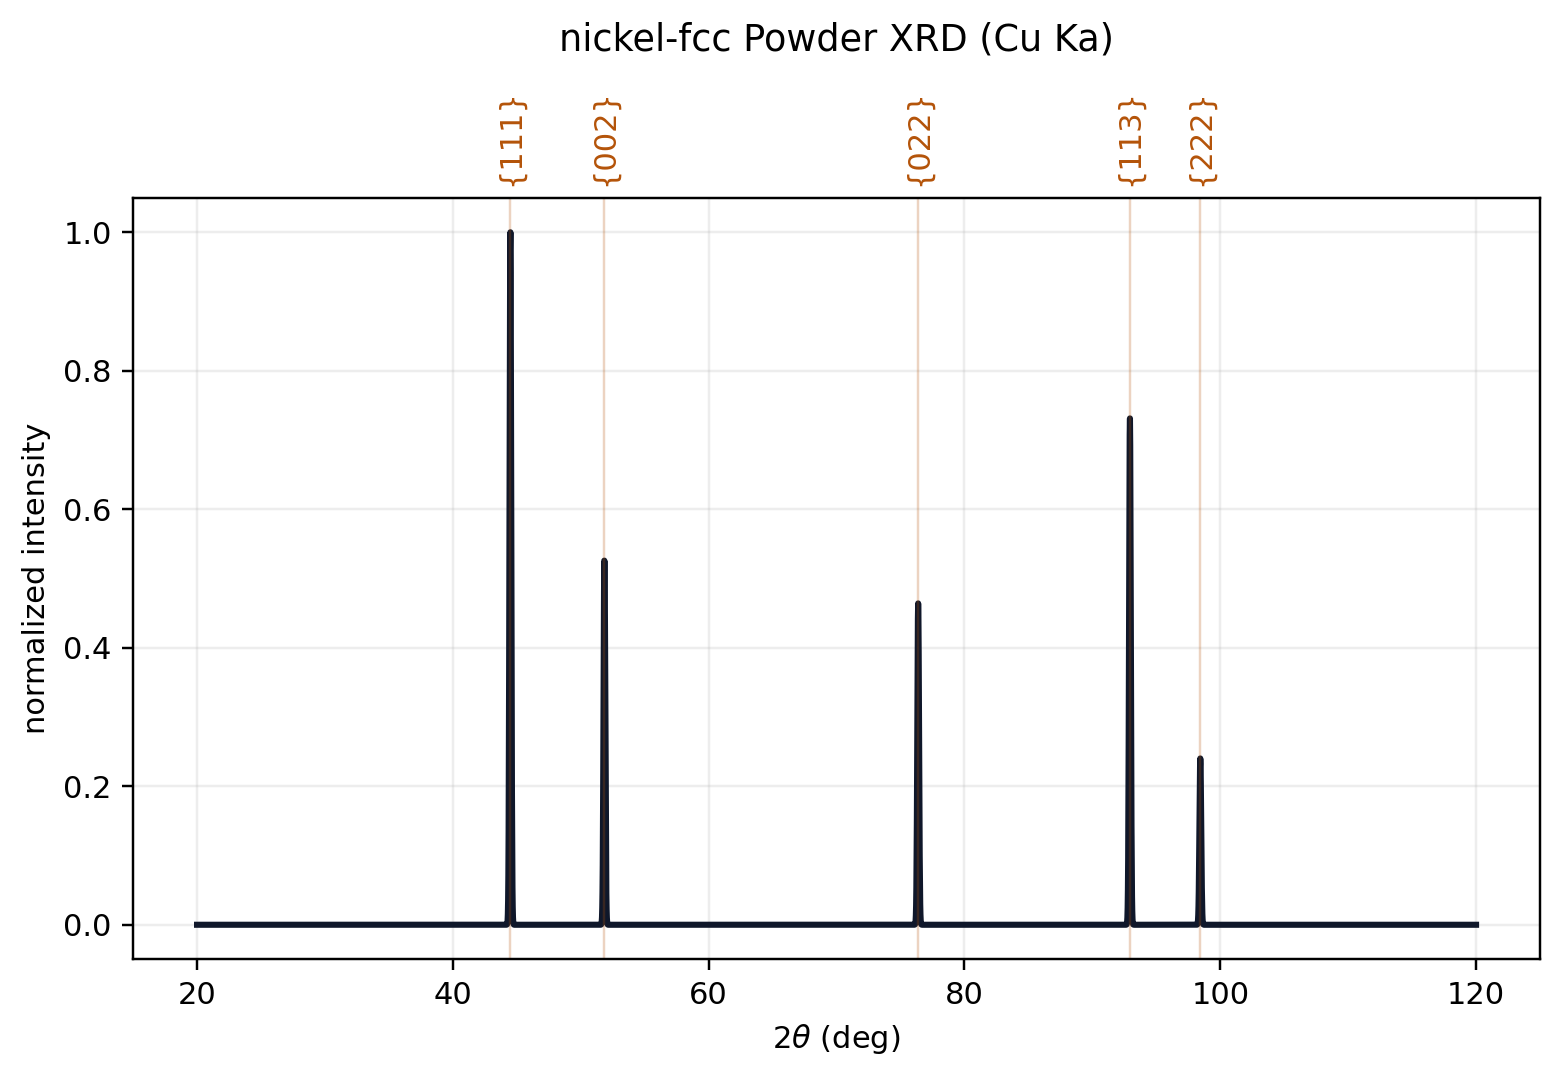

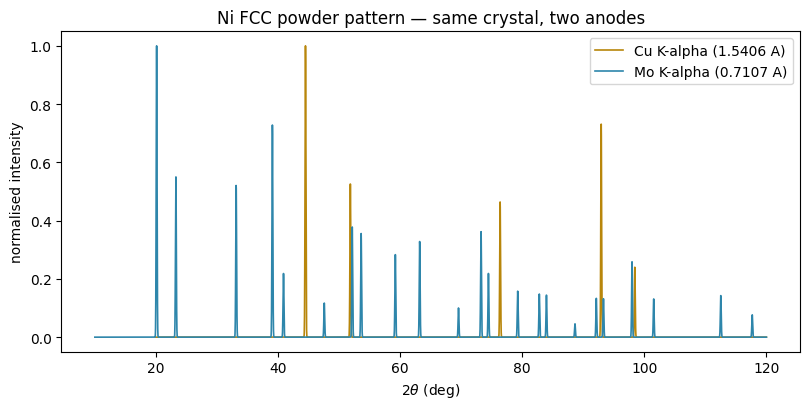

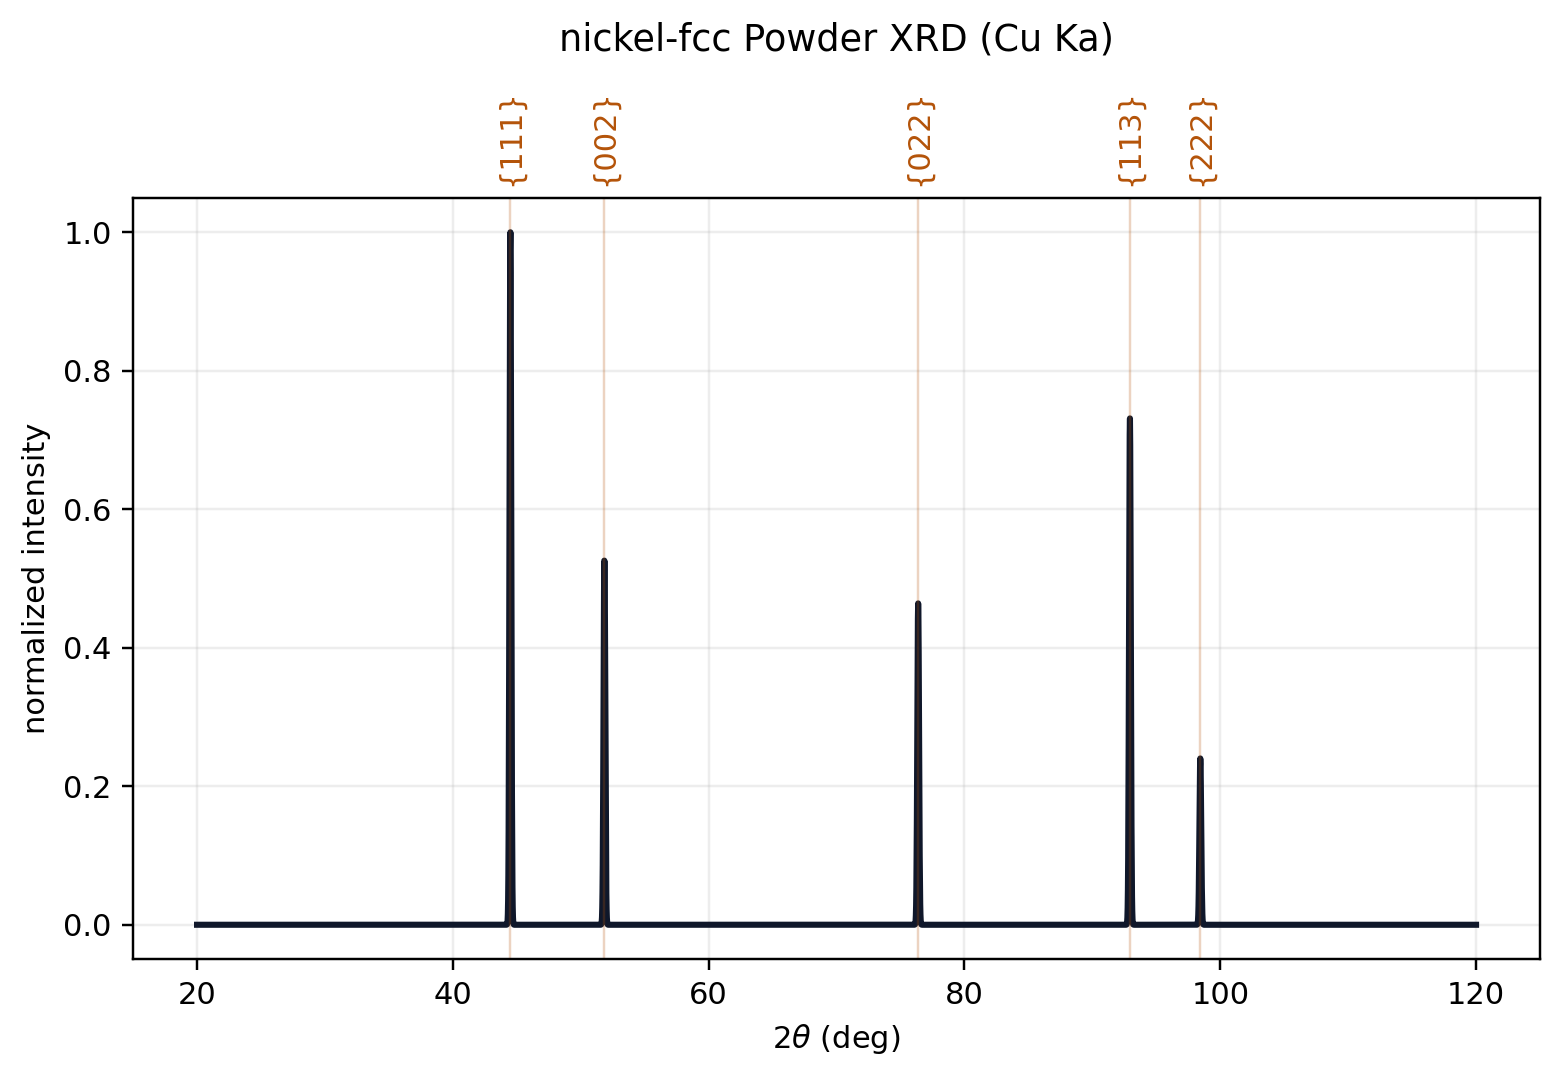

In [5]:
import matplotlib.pyplot as plt

pattern_mo = generate_xrd_pattern(
    nickel, radiation=RadiationSpec.mo_ka(),
    two_theta_range_deg=(10.0, 120.0), resolution_deg=0.02,
    max_index=6, broadening_fwhm_deg=0.16,
)

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.plot(pattern.two_theta_grid_deg, pattern.intensity_grid / pattern.intensity_grid.max(),
        color="#b8860b", lw=1.2, label="Cu K-alpha (1.5406 A)")
ax.plot(pattern_mo.two_theta_grid_deg, pattern_mo.intensity_grid / pattern_mo.intensity_grid.max(),
        color="#2e86ab", lw=1.2, label="Mo K-alpha (0.7107 A)")
ax.set_xlabel(r"$2\theta$ (deg)"); ax.set_ylabel("normalised intensity")
ax.set_title("Ni FCC powder pattern — same crystal, two anodes")
ax.legend()
fig.tight_layout()

# the dedicated helper renders the indexed single-anode pattern
plot_xrd_pattern(pattern, theme="journal")


## Summary and where to go next

- `generate_xrd_pattern` produces peak positions, multiplicities, structure factors,
  and a profile-broadened grid from a `Phase`.
- Peak positions match **Bragg's law** exactly; the reflection list obeys the **FCC
  selection rule** (unmixed parity), a lattice-type fingerprint.
- Changing the **anode** rescales $2\theta$ for every peak.

**Next:** [Notebook 12](12_saed_workflows.ipynb) does the electron-diffraction analogue
(single-crystal SAED spots), and [Notebook 15](15_structure_diffraction_visualization_pipeline.ipynb)
chains structure import → diffraction → visualisation into one manifest-tracked pipeline.